# CNN Development on Custom Dataset

## Objective
The objective of this assignment is to design, train, and evaluate a custom Convolutional Neural Network (CNN) for multi-class image classification on a custom dataset. In this work, I used a garbage classification dataset containing six categories: cardboard, glass, metal, paper, plastic, and trash.

## Assignment Goals
This notebook covers the full deep learning pipeline:
- dataset loading and exploration
- preprocessing and augmentation
- custom CNN model design
- comparison between a plain CNN and a regularized CNN
- training with optimization and learning rate scheduling
- evaluation on the test set using multiple metrics
- confusion matrix analysis and per-class performance discussion
- saving the best trained model

## Dataset Summary
The dataset contains labeled waste images across six classes. Since the task is a multi-class classification problem, the model is trained using cross-entropy loss.

Dataset Link : https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification


In [ ]:
import os
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

In [ ]:
!pip -q install torchinfo
from torchinfo import summary

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = '/content/drive/MyDrive/garbage_project/archive/Garbage classification/Garbage classification'

In [ ]:
print("Dataset path exists:", os.path.exists(DATA_DIR))
print("Folders inside dataset:", os.listdir(DATA_DIR))

Dataset path exists: True
Folders inside dataset: ['paper', 'trash', 'plastic', 'metal', 'glass', 'cardboard']


In [ ]:
full_dataset = datasets.ImageFolder(root=DATA_DIR)
class_names = full_dataset.classes
num_classes = len(class_names)

print("Class Names:", class_names)
print("Number of Classes:", num_classes)
print("Total Images:", len(full_dataset))

Class Names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of Classes: 6
Total Images: 2527


In [ ]:
class_counts = Counter(full_dataset.targets)
class_distribution = {class_names[i]: class_counts[i] for i in range(num_classes)}
class_distribution

{'cardboard': 403,
 'glass': 501,
 'metal': 410,
 'paper': 594,
 'plastic': 482,
 'trash': 137}

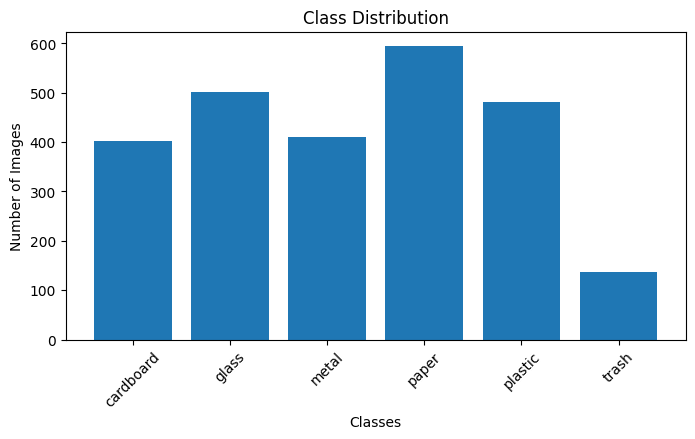

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(class_distribution.keys(), class_distribution.values())
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 2

## 9. Data Preprocessing and Augmentation

To improve model generalization, image preprocessing and augmentation are applied.

### Training Transform
The training images are resized and augmented with random transformations. This helps the model learn more robust features and reduces overfitting.

### Validation/Test Transform
Validation and test images are only resized and normalized, so that evaluation remains consistent and unbiased.

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset_raw, val_dataset_raw, test_dataset_raw = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Train size:", len(train_dataset_raw))
print("Validation size:", len(val_dataset_raw))
print("Test size:", len(test_dataset_raw))

Train size: 1768
Validation size: 379
Test size: 380


In [ ]:
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = TransformedSubset(train_dataset_raw, transform=train_transform)
val_dataset = TransformedSubset(val_dataset_raw, transform=val_test_transform)
test_dataset = TransformedSubset(test_dataset_raw, transform=val_test_transform)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 56
Validation batches: 12
Test batches: 12


In [ ]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img_tensor * std + mean

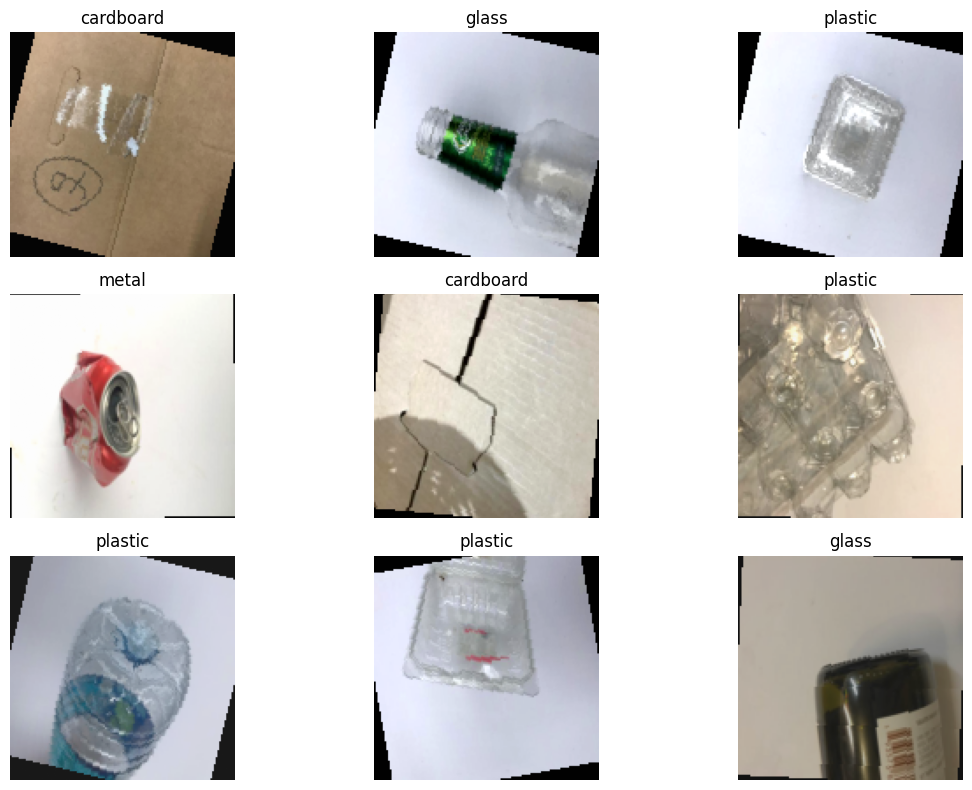

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(class_names[labels[i].item()])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 14. Model A: Plain CNN Architecture

The first model is a simple custom CNN without batch normalization or dropout. It consists of multiple convolutional layers followed by ReLU activation and max pooling, and finally fully connected layers for classification.

### Design Rationale
This model is used as a baseline architecture to understand how a straightforward CNN performs on the dataset before adding regularization techniques.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 15. Model B: Regularized CNN Architecture

The second model extends the plain CNN by including:
- Batch Normalization
- Dropout regularization

### Design Rationale
Batch normalization helps stabilize and speed up training, while dropout reduces overfitting by randomly deactivating neurons during training. This model is included to compare regularized and non-regularized CNN performance, as required in the assignment.

In [ ]:
class RegularizedCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(RegularizedCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
model_plain = SimpleCNN(num_classes=num_classes).to(device)
model_reg = RegularizedCNN(num_classes=num_classes).to(device)

print("Model A: Plain CNN Summary")
summary(model_plain, input_size=(1, 3, IMG_SIZE, IMG_SIZE))

Model A: Plain CNN Summary


Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [1, 6]                    --
├─Sequential: 1-1                        [1, 256, 8, 8]            --
│    └─Conv2d: 2-1                       [1, 32, 128, 128]         896
│    └─ReLU: 2-2                         [1, 32, 128, 128]         --
│    └─MaxPool2d: 2-3                    [1, 32, 64, 64]           --
│    └─Conv2d: 2-4                       [1, 64, 64, 64]           18,496
│    └─ReLU: 2-5                         [1, 64, 64, 64]           --
│    └─MaxPool2d: 2-6                    [1, 64, 32, 32]           --
│    └─Conv2d: 2-7                       [1, 128, 32, 32]          73,856
│    └─ReLU: 2-8                         [1, 128, 32, 32]          --
│    └─MaxPool2d: 2-9                    [1, 128, 16, 16]          --
│    └─Conv2d: 2-10                      [1, 256, 16, 16]          295,168
│    └─ReLU: 2-11                        [1, 256, 16, 16]          --
│

In [ ]:
print("Model B: Regularized CNN Summary")
summary(model_reg, input_size=(1, 3, IMG_SIZE, IMG_SIZE))

Model B: Regularized CNN Summary


Layer (type:depth-idx)                   Output Shape              Param #
RegularizedCNN                           [1, 6]                    --
├─Sequential: 1-1                        [1, 256, 8, 8]            --
│    └─Conv2d: 2-1                       [1, 32, 128, 128]         896
│    └─BatchNorm2d: 2-2                  [1, 32, 128, 128]         64
│    └─ReLU: 2-3                         [1, 32, 128, 128]         --
│    └─MaxPool2d: 2-4                    [1, 32, 64, 64]           --
│    └─Conv2d: 2-5                       [1, 64, 64, 64]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 64, 64]           128
│    └─ReLU: 2-7                         [1, 64, 64, 64]           --
│    └─MaxPool2d: 2-8                    [1, 64, 32, 32]           --
│    └─Conv2d: 2-9                       [1, 128, 32, 32]          73,856
│    └─BatchNorm2d: 2-10                 [1, 128, 32, 32]          256
│    └─ReLU: 2-11                        [1, 128, 32, 32]          --
│   

## 18. Training Configuration

The models are trained using the following strategy:
- Loss Function: CrossEntropyLoss
- Optimizer: Adam
- Learning Rate Scheduler: StepLR
- Epochs: 15

Cross-entropy loss is suitable for multi-class classification, while Adam is chosen for faster and more stable convergence.

In [ ]:
EPOCHS = 15
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4

In [ ]:
hyperparameters = {
    'Image Size': IMG_SIZE,
    'Batch Size': BATCH_SIZE,
    'Epochs': EPOCHS,
    'Learning Rate': LEARNING_RATE,
    'Weight Decay': WEIGHT_DECAY,
    'Loss Function': 'CrossEntropyLoss',
    'Optimizer': 'Adam',
    'Scheduler': 'StepLR(step_size=5, gamma=0.5)'
}

pd.DataFrame(hyperparameters.items(), columns=['Hyperparameter', 'Value'])

,Hyperparameter,Value
0,Image Size,128
1,Batch Size,32
2,Epochs,15
3,Learning Rate,0.001
4,Weight Decay,0.0001
5,Loss Function,CrossEntropyLoss
6,Optimizer,Adam
7,Scheduler,"StepLR(step_size=5, gamma=0.5)"


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_labels, all_preds

In [ ]:
def train_model(model, train_loader, val_loader, epochs, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val_acc = 0.0
    best_model_path = None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_path = f'best_{model.__class__.__name__}.pth'
            torch.save(model.state_dict(), best_model_path)

        scheduler.step()

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return history, best_model_path, best_val_acc

In [ ]:
model_plain = SimpleCNN(num_classes=num_classes).to(device)
history_plain, best_path_plain, best_val_acc_plain = train_model(
    model_plain, train_loader, val_loader, EPOCHS, lr=LEARNING_RATE
)

print("Best saved path:", best_path_plain)
print("Best validation accuracy:", best_val_acc_plain)

Epoch [1/15] | Train Loss: 1.5991, Train Acc: 0.3218 | Val Loss: 1.4377, Val Acc: 0.4090
Epoch [2/15] | Train Loss: 1.3890, Train Acc: 0.4191 | Val Loss: 1.3538, Val Acc: 0.4485
Epoch [3/15] | Train Loss: 1.2915, Train Acc: 0.4768 | Val Loss: 1.2541, Val Acc: 0.4987
Epoch [4/15] | Train Loss: 1.2248, Train Acc: 0.5170 | Val Loss: 1.1539, Val Acc: 0.5277
Epoch [5/15] | Train Loss: 1.1464, Train Acc: 0.5475 | Val Loss: 1.1054, Val Acc: 0.5303
Epoch [6/15] | Train Loss: 1.0617, Train Acc: 0.5928 | Val Loss: 1.0583, Val Acc: 0.5752
Epoch [7/15] | Train Loss: 0.9955, Train Acc: 0.6239 | Val Loss: 1.0239, Val Acc: 0.5858
Epoch [8/15] | Train Loss: 0.9249, Train Acc: 0.6555 | Val Loss: 1.0368, Val Acc: 0.6201
Epoch [9/15] | Train Loss: 0.8915, Train Acc: 0.6742 | Val Loss: 0.9274, Val Acc: 0.6755
Epoch [10/15] | Train Loss: 0.8224, Train Acc: 0.7008 | Val Loss: 0.9455, Val Acc: 0.6438
Epoch [11/15] | Train Loss: 0.7722, Train Acc: 0.7166 | Val Loss: 0.8971, Val Acc: 0.6596
Epoch [12/15] | Tra

In [ ]:
def plot_history(history, title_prefix='Model'):
    epochs_range = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss')
    plt.plot(epochs_range, history['val_loss'], label='Validation Loss')
    plt.title(f'{title_prefix} Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Accuracy')
    plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy')
    plt.title(f'{title_prefix} Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train samples: 1768
Val samples: 379
Test samples: 380
Train batches: 56
Val batches: 12
Test batches: 12


In [ ]:
print(history_plain)

{'train_loss': [1.5990627534788657, 1.388955347138832, 1.2914834173556367, 1.224790192297681, 1.1464458892787743, 1.0617323061999153, 0.9954579610090989, 0.9248808859699992, 0.8914968368694254, 0.8224445805290705, 0.7722368445331694, 0.7242380720457879, 0.7072377728121313, 0.6349317223777599, 0.6312726277571458], 'train_acc': [0.3218325791855204, 0.41911764705882354, 0.47680995475113125, 0.5169683257918553, 0.5475113122171946, 0.5927601809954751, 0.623868778280543, 0.6555429864253394, 0.6742081447963801, 0.7007918552036199, 0.7166289592760181, 0.745475113122172, 0.7505656108597285, 0.7686651583710408, 0.7709276018099548], 'val_loss': [1.4377437773354764, 1.3538153866664715, 1.2540696437880987, 1.153893518259154, 1.1053753940285354, 1.0582858122747618, 1.023930323469922, 1.0368128818383633, 0.9273501945988799, 0.9454894465318141, 0.8971302282841664, 0.8234236411809293, 0.8179420495410707, 0.8123107219119814, 0.8275872472093728], 'val_acc': [0.40897097625329815, 0.44854881266490765, 0.49

In [ ]:
train_indices = set(train_dataset_raw.indices)
val_indices = set(val_dataset_raw.indices)
test_indices = set(test_dataset_raw.indices)

print("Train-Val overlap:", len(train_indices.intersection(val_indices)))
print("Train-Test overlap:", len(train_indices.intersection(test_indices)))
print("Val-Test overlap:", len(val_indices.intersection(test_indices)))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [ ]:
model_reg = RegularizedCNN(num_classes=num_classes).to(device)
history_reg, best_path_reg, best_val_acc_reg = train_model(
    model_reg, train_loader, val_loader, EPOCHS, lr=LEARNING_RATE
)

print("Best saved path:", best_path_reg)
print("Best validation accuracy:", best_val_acc_reg)

Epoch [1/15] | Train Loss: 3.3794, Train Acc: 0.2992 | Val Loss: 1.5297, Val Acc: 0.3562
Epoch [2/15] | Train Loss: 1.5480, Train Acc: 0.3852 | Val Loss: 1.3521, Val Acc: 0.4617
Epoch [3/15] | Train Loss: 1.4406, Train Acc: 0.4152 | Val Loss: 1.2860, Val Acc: 0.5119
Epoch [4/15] | Train Loss: 1.3838, Train Acc: 0.4440 | Val Loss: 1.2207, Val Acc: 0.5198
Epoch [5/15] | Train Loss: 1.3567, Train Acc: 0.4581 | Val Loss: 1.1519, Val Acc: 0.5699
Epoch [6/15] | Train Loss: 1.2637, Train Acc: 0.5045 | Val Loss: 1.1067, Val Acc: 0.5726
Epoch [7/15] | Train Loss: 1.2788, Train Acc: 0.5107 | Val Loss: 1.1372, Val Acc: 0.5409
Epoch [8/15] | Train Loss: 1.2146, Train Acc: 0.5424 | Val Loss: 1.0593, Val Acc: 0.5778
Epoch [9/15] | Train Loss: 1.1969, Train Acc: 0.5532 | Val Loss: 1.1703, Val Acc: 0.5409
Epoch [10/15] | Train Loss: 1.1560, Train Acc: 0.5436 | Val Loss: 1.0567, Val Acc: 0.5646
Epoch [11/15] | Train Loss: 1.1431, Train Acc: 0.5588 | Val Loss: 1.0106, Val Acc: 0.6042
Epoch [12/15] | Tra

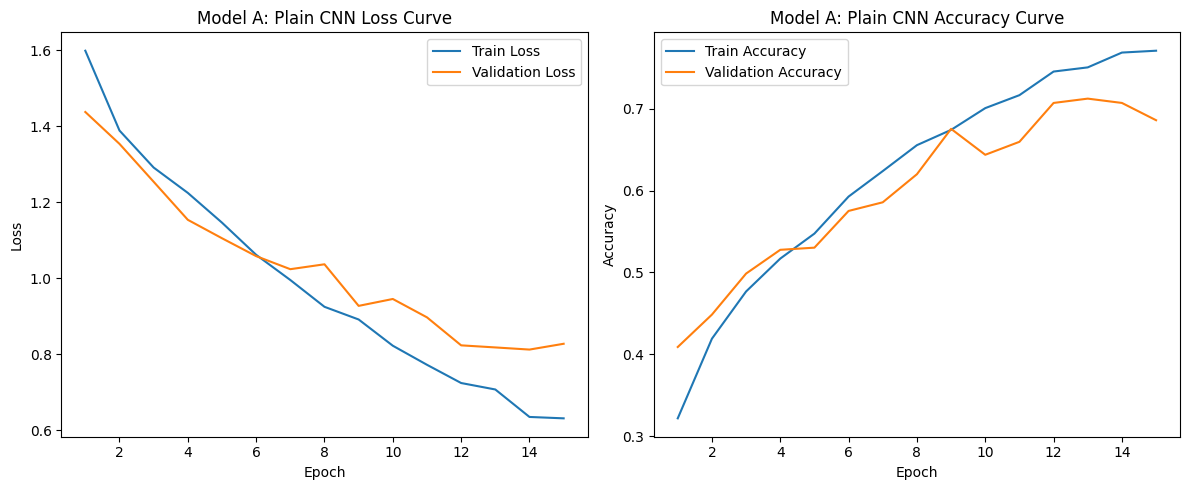

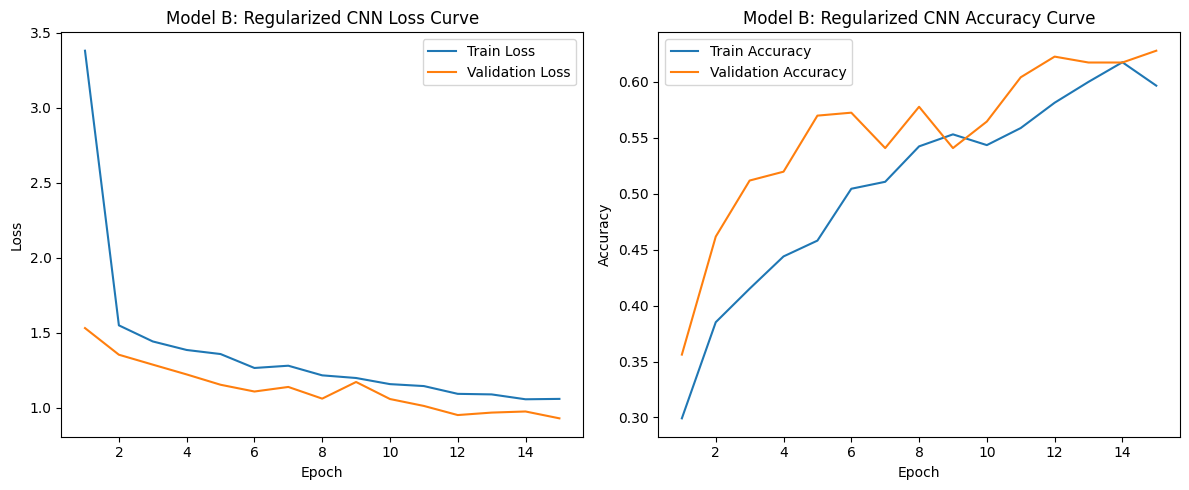

In [ ]:
plot_history(history_plain, title_prefix='Model A: Plain CNN')
plot_history(history_reg, title_prefix='Model B: Regularized CNN')

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Model A: Plain CNN', 'Model B: Regularized CNN'],
    'BatchNorm': ['No', 'Yes'],
    'Dropout': ['No', 'Yes'],
    'Best Validation Accuracy': [best_val_acc_plain, best_val_acc_reg]
})
comparison_df

,Model,BatchNorm,Dropout,Best Validation Accuracy
0,Model A: Plain CNN,No,No,0.712401
1,Model B: Regularized CNN,Yes,Yes,0.627968


In [ ]:
if best_val_acc_reg >= best_val_acc_plain:
    best_model = RegularizedCNN(num_classes=num_classes).to(device)
    best_model.load_state_dict(torch.load(best_path_reg, map_location=device))
    best_model_name = 'Model B: Regularized CNN'
    best_model_path = best_path_reg
else:
    best_model = SimpleCNN(num_classes=num_classes).to(device)
    best_model.load_state_dict(torch.load(best_path_plain, map_location=device))
    best_model_name = 'Model A: Plain CNN'
    best_model_path = best_path_plain

print("Selected Best Model:", best_model_name)
print("Model Path:", best_model_path)

Selected Best Model: Model A: Plain CNN
Model Path: best_SimpleCNN.pth


In [ ]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate(best_model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.7954
Test Accuracy: 0.7395


In [ ]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)

print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-score (weighted): {f1:.4f}")

Precision (weighted): 0.7444
Recall (weighted): 0.7395
F1-score (weighted): 0.7373


In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

   cardboard       0.85      0.86      0.86        59
       glass       0.78      0.65      0.71        78
       metal       0.61      0.82      0.70        61
       paper       0.83      0.86      0.84        92
     plastic       0.63      0.56      0.59        66
       trash       0.68      0.54      0.60        24

    accuracy                           0.74       380
   macro avg       0.73      0.72      0.72       380
weighted avg       0.74      0.74      0.74       380



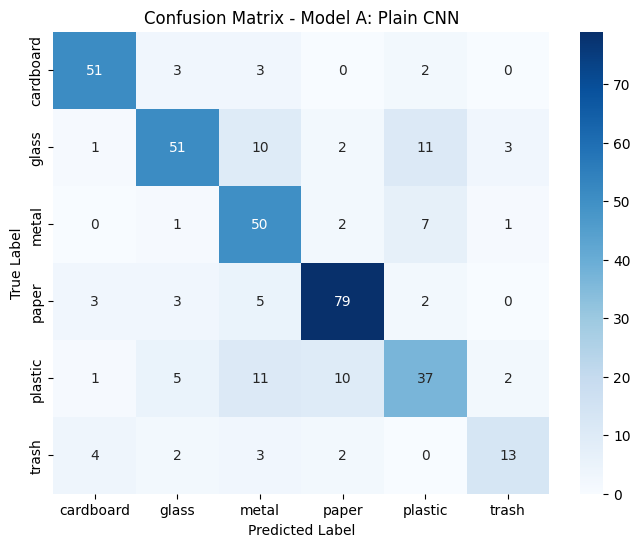

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

In [ ]:
report_dict = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_df

,precision,recall,f1-score,support
cardboard,0.850000,0.864407,0.857143,59.000000
glass,0.784615,0.653846,0.713287,78.000000
metal,0.609756,0.819672,0.699301,61.000000
paper,0.831579,0.858696,0.844920,92.000000
plastic,0.627119,0.560606,0.592000,66.000000
trash,0.684211,0.541667,0.604651,24.000000
accuracy,0.739474,0.739474,0.739474,0.739474
macro avg,0.731213,0.716482,0.718550,380.000000
weighted avg,0.744372,0.739474,0.737319,380.000000


In [ ]:
class_metrics_df = report_df.loc[class_names, ['precision', 'recall', 'f1-score', 'support']]
class_metrics_df = class_metrics_df.sort_values(by='f1-score', ascending=False)
class_metrics_df

,precision,recall,f1-score,support
cardboard,0.850000,0.864407,0.857143,59.0
paper,0.831579,0.858696,0.844920,92.0
glass,0.784615,0.653846,0.713287,78.0
metal,0.609756,0.819672,0.699301,61.0
trash,0.684211,0.541667,0.604651,24.0
plastic,0.627119,0.560606,0.592000,66.0


In [ ]:
final_model_name = 'best_garbage_classifier.pth'
torch.save(best_model.state_dict(), final_model_name)
print("Final model saved as:", final_model_name)

Final model saved as: best_garbage_classifier.pth


In [ ]:
from google.colab import files
files.download(final_model_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 33. Analysis and Discussion of Results

### Overall Performance
Among the two tested architectures, **Model A (Plain CNN)** performed better than **Model B (Regularized CNN)** on the validation set. The best validation accuracy of Model A was **71.24%**, whereas Model B achieved **62.80%**. Therefore, Model A was selected as the final model.

On the test set, the selected model achieved:
- **Test Accuracy:** 73.95%
- **Weighted Precision:** 74.44%
- **Weighted Recall:** 73.95%
- **Weighted F1-score:** 73.73%

These results indicate that the CNN learned useful visual patterns from the dataset and achieved reasonably strong multi-class classification performance.

### Comparison Between Plain CNN and Regularized CNN
An interesting observation is that the plain CNN outperformed the regularized CNN. Although batch normalization and dropout are usually introduced to improve generalization, in this experiment the regularized model did not achieve better validation accuracy.

Possible reasons include:
1. The baseline CNN was already sufficiently expressive for this dataset.
2. The regularized model may have become harder to optimize within only 15 epochs.
3. Dropout may have reduced effective feature learning capacity for this relatively moderate-sized dataset.
4. The dataset itself may not have been large enough for the regularization benefits to become dominant.

### Training Behavior
The training and validation curves show that both models improved steadily during training. For the plain CNN, validation accuracy increased consistently and reached its best value around the later epochs. The validation loss also decreased overall, which suggests that the model learned meaningful features without severe instability.

The plain CNN showed better convergence than the regularized CNN. This suggests that, for this dataset and training setup, the simpler architecture was more effective.

### Per-Class Performance
The best performing class was **cardboard**, with an F1-score of approximately **0.857**. The class **paper** also performed very well, with an F1-score of about **0.845**. These classes likely had more distinctive visual textures and clearer structural patterns, making them easier for the CNN to classify.

The most difficult class was **plastic**, with an F1-score of around **0.592**. The **trash** class also performed relatively poorly, with an F1-score of about **0.605**. These lower scores may be due to:
- fewer training samples, especially for `trash`
- greater visual variation within the class
- similarity with other classes such as paper, metal, or glass in some images

### Confusion Matrix Insights
The confusion matrix suggests that the model classified `cardboard` and `paper` more reliably than the other classes. In contrast, `plastic` and `trash` were more frequently misclassified. This behavior is consistent with the class-wise metrics and indicates that visually ambiguous or underrepresented classes remain challenging.

### Effect of Class Imbalance
The dataset is not perfectly balanced. For example, `paper` contains many more images than `trash`. This imbalance likely contributed to better performance on majority classes and weaker performance on minority classes. A more balanced dataset or class-weighted loss may improve performance further.

### Final Interpretation
Overall, the experiment demonstrates that a well-designed custom CNN can achieve strong performance on a real-world garbage classification task. The model generalized reasonably well to the test set, and the evaluation metrics show that the chosen model is effective, although improvement is still possible for difficult classes such as plastic and trash.

## 34. Conclusion and Future Work

### Conclusion
In this assignment, I developed and evaluated a custom CNN for six-class garbage image classification using PyTorch. The full pipeline included dataset loading, preprocessing, augmentation, custom architecture design, training, model comparison, evaluation, confusion matrix analysis, and model saving.

Two architectures were tested:
- a plain CNN
- a regularized CNN with batch normalization and dropout

The **plain CNN** achieved the best performance and was selected as the final model. It obtained a **test accuracy of 73.95%** with a **weighted F1-score of 73.73%**. The results show that the model was able to learn meaningful image features and perform reasonably well on the classification task.

### Future Work
The following improvements may further enhance performance:
- collect more training images, especially for minority classes such as `trash`
- apply stronger and more diverse data augmentation
- tune hyperparameters such as learning rate, dropout rate, and batch size
- train for more epochs
- use transfer learning models such as ResNet or EfficientNet
- apply class weighting or oversampling to reduce the effect of class imbalance
- perform deeper error analysis on visually confusing classes